# Penalty Evolution Analysis

**Paper 2: Cross-Code Comparative Analysis - Part 11**

This notebook tracks how penalties (fines, imprisonment terms) have changed over time across historical versions of Kazakhstan legal codes.

## Objectives
1. Extract penalties from historical versions (УК, КоАП)
2. Track MRP fine value changes over time
3. Track imprisonment term changes over time
4. Identify penalty inflation/deflation trends
5. Find articles with most penalty changes

## 1. Setup and Imports

In [3]:
import json
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime
from collections import defaultdict
import re
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Paths
DATA_DIR = Path('../data/raw/by_history')
OUTPUT_03 = Path('../output/03')
OUTPUT_DIR = Path('../output/11')
OUTPUT_DIR.mkdir(exist_ok=True)

# Code metadata - only УК and КоАП have penalties
CODES = {
    'criminal': {'folder': 'K1400000226_rus_ugolov', 'short': 'УК', 'name': 'Уголовный кодекс'},
    'administrative': {'folder': 'K1400000235_rus_adm', 'short': 'КоАП', 'name': 'Кодекс об административных правонарушениях'},
}

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("Setup complete!")

Setup complete!


## 2. Penalty Extraction Functions

Adapted from notebook 03.

In [45]:
# Russian number word dictionaries for parsing compound numbers (from notebook 03)
# MRP = Месячный Расчетный Показатель (Monthly Calculation Index)

UNITS = {
    'один': 1, 'одного': 1, 'одному': 1, 'одним': 1, 'одной': 1, 'одна': 1,
    'два': 2, 'двух': 2, 'двум': 2, 'двумя': 2, 'две': 2,
    'три': 3, 'трех': 3, 'трём': 3, 'тремя': 3,
    'четыре': 4, 'четырех': 4, 'четырём': 4, 'четырьмя': 4,
    'пять': 5, 'пяти': 5, 'пятью': 5,
    'шесть': 6, 'шести': 6, 'шестью': 6,
    'семь': 7, 'семи': 7, 'семью': 7,
    'восемь': 8, 'восьми': 8, 'восемью': 8,
    'девять': 9, 'девяти': 9, 'девятью': 9,
}

TEENS = {
    'десять': 10, 'десяти': 10, 'десятью': 10,
    'одиннадцать': 11, 'одиннадцати': 11,
    'двенадцать': 12, 'двенадцати': 12,
    'тринадцать': 13, 'тринадцати': 13,
    'четырнадцать': 14, 'четырнадцати': 14,
    'пятнадцать': 15, 'пятнадцати': 15,
    'шестнадцать': 16, 'шестнадцати': 16,
    'семнадцать': 17, 'семнадцати': 17,
    'восемнадцать': 18, 'восемнадцати': 18,
    'девятнадцать': 19, 'девятнадцати': 19,
}

TENS = {
    'двадцать': 20, 'двадцати': 20,
    'тридцать': 30, 'тридцати': 30,
    'сорок': 40, 'сорока': 40,
    'пятьдесят': 50, 'пятидесяти': 50,
    'шестьдесят': 60, 'шестидесяти': 60,
    'семьдесят': 70, 'семидесяти': 70,
    'восемьдесят': 80, 'восьмидесяти': 80,
    'девяносто': 90, 'девяноста': 90,
}

HUNDREDS = {
    'сто': 100, 'ста': 100,
    'двести': 200, 'двухсот': 200,
    'триста': 300, 'трехсот': 300,
    'четыреста': 400, 'четырехсот': 400,
    'пятьсот': 500, 'пятисот': 500,
    'шестьсот': 600, 'шестисот': 600,
    'семьсот': 700, 'семисот': 700,
    'восемьсот': 800, 'восьмисот': 800,
    'девятьсот': 900, 'девятисот': 900,
}

THOUSANDS = {'тысяча': 1000, 'тысячи': 1000, 'тысяч': 1000}

# Combined lookup for simple cases
RUSSIAN_NUMBERS = {**UNITS, **TEENS, **TENS, **HUNDREDS, **THOUSANDS}

def parse_compound_russian_number(text):
    """Parse compound Russian numbers like 'ста двадцати' → 120, 'одной тысячи' → 1000"""
    if text is None:
        return None
    
    text = text.strip().lower()
    
    # Remove leading "до" or "от" if present
    text = re.sub(r'^(до|от)\s+', '', text)
    
    # Try direct digit match first
    if text.isdigit():
        return int(text)
    
    # Try simple lookup
    if text in RUSSIAN_NUMBERS:
        return RUSSIAN_NUMBERS[text]
    
    # Parse compound number word by word
    words = text.split()
    total = 0
    current = 0
    
    for word in words:
        if word in THOUSANDS:
            current = (current if current else 1) * 1000
            total += current
            current = 0
        elif word in HUNDREDS:
            current += HUNDREDS[word]
        elif word in TENS:
            current += TENS[word]
        elif word in TEENS:
            current += TEENS[word]
        elif word in UNITS:
            current += UNITS[word]
        elif word.isdigit():
            current += int(word)
    
    result = total + current
    return result if result > 0 else None

def extract_number_from_text(text):
    """Extract number from text - handles both digits and Russian words."""
    if not text:
        return None
    
    text = text.strip().lower()
    
    # Try digit pattern first
    digit_match = re.search(r'(\d+)', text)
    if digit_match:
        return int(digit_match.group(1))
    
    # Try compound Russian number
    return parse_compound_russian_number(text)

print(f"Russian number dictionaries loaded: {len(RUSSIAN_NUMBERS)} words")

# Test compound number parsing
test_cases = [
    ("семисот пятидесяти", 750),
    ("тысячи пятисот", 1500),
    ("одной тысячи", 1000),
    ("ста двадцати", 120),
    ("до ста двадцати", 120),
    ("100", 100),
]
print("\nTesting compound number parsing:")
for text, expected in test_cases:
    result = parse_compound_russian_number(text)
    status = "✓" if result == expected else f"✗ (got {result})"
    print(f"  '{text}' → {expected} {status}")

Russian number dictionaries loaded: 92 words

Testing compound number parsing:
  'семисот пятидесяти' → 750 ✓
  'тысячи пятисот' → 1500 ✓
  'одной тысячи' → 1000 ✓
  'ста двадцати' → 120 ✓
  'до ста двадцати' → 120 ✓
  '100' → 100 ✓


In [47]:
# Full penalty patterns from notebook 03 (15 patterns)
# Patterns handle three formats:
# 1. "от X до Y" (range) - captures min and max
# 2. "до X" (only max) - captures max only
# 3. "X" (exact) - captures as both min and max

# Word pattern for Russian numbers (single or compound)
RU_NUM_WORD = r'(?:\d+|[а-яё]+(?:\s+[а-яё]+){0,3})'

PENALTY_PATTERNS = {
    "fine_mrp": {
        # Primary pattern: "штраф в размере X месячных"
        "pattern": r'штраф\w*\s+(?:в\s+размере\s+)?(?:от\s+([^,]+?)\s+до\s+([^,]+?)|до\s+([^,]+?)|([^,]+?))\s+месячн',
        "groups": ["min", "max", "max_only", "exact"],
        "value_type": "mrp"
    },
    "fine_mrp_subject": {
        # Admin Code multi-subject pattern: "штраф на физических лиц в размере X,"
        "pattern": r'штраф\w*\s+на\s+(?:физическ|должностн|юридическ)\w+\s+(?:лиц\w*\s+)?в\s+размере\s+(\d+|[а-яё]+(?:\s+[а-яё]+)?)\s*(?:,|месячн)',
        "groups": ["exact"],
        "value_type": "mrp"
    },
    "imprisonment_years": {
        # Fixed pattern - only matches when values are present
        # Matches: "лишением свободы на срок от X до Y лет" or "лишением свободы на срок до X лет"
        "pattern": r'лишени\w*\s+свободы\s+на\s+срок\s+(?:от\s+(' + RU_NUM_WORD + r')\s+до\s+(' + RU_NUM_WORD + r')|до\s+(' + RU_NUM_WORD + r'))\s*(?:года?|лет)',
        "groups": ["min", "max", "max_only"],
        "value_type": "years"
    },
    "restriction_freedom": {
        # Fixed pattern - same structure as imprisonment
        "pattern": r'ограничени\w*\s+свободы\s+на\s+срок\s+(?:от\s+(' + RU_NUM_WORD + r')\s+до\s+(' + RU_NUM_WORD + r')|до\s+(' + RU_NUM_WORD + r'))\s*(?:года?|лет)',
        "groups": ["min", "max", "max_only"],
        "value_type": "years"
    },
    "correctional_work": {
        "pattern": r'исправительн\w+\s+работ\w*\s+(?:на\s+срок\s+)?(?:от\s+(' + RU_NUM_WORD + r')\s+до\s+(' + RU_NUM_WORD + r')|до\s+(' + RU_NUM_WORD + r'))\s*(?:года?|лет|месяц)',
        "groups": ["min", "max", "max_only"],
        "value_type": "months"
    },
    "community_service_hours": {
        "pattern": r'общественн\w+\s+работ\w*\s+(?:на\s+срок\s+)?(?:от\s+(' + RU_NUM_WORD + r')\s+до\s+(' + RU_NUM_WORD + r')|до\s+(' + RU_NUM_WORD + r'))\s*час',
        "groups": ["min", "max", "max_only"],
        "value_type": "hours"
    },
    "arrest_days": {
        "pattern": r'(?:административн\w+\s+)?арест\w*\s+(?:на\s+срок\s+)?(?:до\s+)?(' + RU_NUM_WORD + r')\s*(?:суток|сутки|дней)',
        "groups": ["max"],
        "value_type": "days"
    },
    "warning": {
        "pattern": r'предупреждени[еяю]м?(?:\s|,|;|$)',
        "groups": [],
        "value_type": None
    },
    "confiscation": {
        "pattern": r'конфискаци[еяюи]',
        "groups": [],
        "value_type": None
    },
    "life_imprisonment": {
        "pattern": r'пожизненн\w+\s+(?:лишени\w+\s+свободы|заключени)',
        "groups": [],
        "value_type": None
    },
    "deprivation_right": {
        "pattern": r'лишени\w*\s+права\s+заним',
        "groups": [],
        "value_type": None
    },
    "suspension": {
        "pattern": r'приостановлени\w*\s+(?:деятельности|лицензии|действия|разрешения)',
        "groups": [],
        "value_type": None
    },
    "deportation": {
        "pattern": r'(?:выдворени\w*|депортаци\w+)',
        "groups": [],
        "value_type": None
    },
    "license_revocation": {
        "pattern": r'лишени\w*\s+(?:специального\s+права|лицензии|разрешения)',
        "groups": [],
        "value_type": None
    },
    "death_penalty_mention": {
        "pattern": r'смертн\w+\s+казн[ьи]',
        "groups": [],
        "value_type": None
    },
}

# Types that have quantitative values (for evolution tracking)
QUANTITATIVE_TYPES = [
    'fine_mrp', 'fine_mrp_subject', 'imprisonment_years', 'restriction_freedom',
    'correctional_work', 'community_service_hours', 'arrest_days'
]

print(f"Defined {len(PENALTY_PATTERNS)} penalty patterns")
print(f"Quantitative types (for evolution tracking): {len(QUANTITATIVE_TYPES)}")

# Test imprisonment pattern
import re
test_text = "лишением свободы на срок от пяти до десяти лет"
match = re.search(PENALTY_PATTERNS['imprisonment_years']['pattern'], test_text)
if match:
    print(f"\nTest match: '{test_text}'")
    print(f"  Groups: {match.groups()}")

Defined 15 penalty patterns
Quantitative types (for evolution tracking): 7

Test match: 'лишением свободы на срок от пяти до десяти лет'
  Groups: ('пяти', 'десяти', None)


In [48]:
def parse_penalty_value(penalty_text, penalty_type):
    """Extract penalty values (min/max) from text using PENALTY_PATTERNS."""
    if penalty_type not in PENALTY_PATTERNS:
        return None, None
    
    config = PENALTY_PATTERNS[penalty_type]
    match = re.search(config["pattern"], penalty_text.lower(), re.IGNORECASE)
    
    if not match:
        return None, None
    
    groups = config["groups"]
    if not groups:
        # Non-quantitative type (warning, confiscation, etc.)
        return None, None
    
    min_val = None
    max_val = None
    
    # Check if lastindex is None
    if match.lastindex is None:
        return None, None
    
    for i, group_name in enumerate(groups):
        group_idx = i + 1
        if group_idx <= match.lastindex and match.group(group_idx):
            value = extract_number_from_text(match.group(group_idx))
            
            if group_name == "min":
                min_val = value
            elif group_name == "max":
                max_val = value
            elif group_name == "max_only":
                max_val = value
            elif group_name == "exact":
                min_val = value
                max_val = value
    
    return min_val, max_val


def extract_article_penalties(article):
    """Extract all penalties from an article text using all 15 patterns."""
    text = article.get('article_text', '')
    if not text:
        return []
    
    text_lower = text.lower()
    penalties = []
    
    # Try each pattern
    for penalty_type, config in PENALTY_PATTERNS.items():
        match = re.search(config["pattern"], text_lower, re.IGNORECASE)
        if match:
            min_val, max_val = parse_penalty_value(text, penalty_type)
            
            penalty = {
                'type': penalty_type,
                'value_type': config['value_type'],
                'min': min_val,
                'max': max_val
            }
            penalties.append(penalty)
    
    return penalties


def extract_article_number(title):
    """Extract article number from title."""
    match = re.search(r'Статья\s+([\d\-]+)', title)
    return match.group(1) if match else None


print("Extraction functions defined:")
print("  - parse_penalty_value(text, type)")
print("  - extract_article_penalties(article)")
print("  - extract_article_number(title)")

Extraction functions defined:
  - parse_penalty_value(text, type)
  - extract_article_penalties(article)
  - extract_article_number(title)


## 3. Load Historical Versions

In [49]:
def get_version_list(code_folder):
    """Build version list from directory listing."""
    folder_path = DATA_DIR / code_folder
    version_files = sorted(folder_path.glob('version_*.json'))
    
    versions = []
    for vf in version_files:
        parts = vf.stem.split('_')
        version_num = int(parts[1])
        version_date = parts[2]
        versions.append({
            'version_number': version_num,
            'version_date': version_date,
            'filename': vf.name
        })
    return versions

def load_version_file(code_folder, filename):
    """Load a specific version file."""
    filepath = DATA_DIR / code_folder / filename
    with open(filepath, 'r', encoding='utf-8') as f:
        return json.load(f)

# Build version indices
all_indices = {}
for code_key, code_info in CODES.items():
    versions = get_version_list(code_info['folder'])
    all_indices[code_key] = {
        'total_versions': len(versions),
        'versions': versions
    }
    print(f"{code_info['short']}: {len(versions)} versions")

УК: 109 versions
КоАП: 205 versions


## 4. Extract Penalties from All Versions

In [50]:
# Extract penalties from all versions using full 15 patterns
all_penalties = []

for code_key in ['criminal', 'administrative']:
    code_info = CODES[code_key]
    versions = all_indices[code_key]['versions']
    
    print(f"\nProcessing {code_info['short']} ({len(versions)} versions)...")
    
    for version in tqdm(versions, desc=code_info['short']):
        try:
            data = load_version_file(code_info['folder'], version['filename'])
            
            for article in data.get('articles', []):
                art_num = extract_article_number(article.get('article_title', ''))
                if not art_num:
                    continue
                
                penalties = extract_article_penalties(article)
                
                for penalty in penalties:
                    all_penalties.append({
                        'code_key': code_key,
                        'code_short': code_info['short'],
                        'version_number': version['version_number'],
                        'version_date': version['version_date'],
                        'article_number': art_num,
                        'penalty_type': penalty['type'],
                        'value_type': penalty['value_type'],
                        'penalty_min': penalty['min'],
                        'penalty_max': penalty['max']
                    })
                    
        except Exception as e:
            print(f"  Error processing {version['filename']}: {e}")

penalties_df = pd.DataFrame(all_penalties)
penalties_df['version_date'] = pd.to_datetime(penalties_df['version_date'])
penalties_df['year'] = penalties_df['version_date'].dt.year

print(f"\nTotal penalty records: {len(penalties_df):,}")


Processing УК (109 versions)...


УК: 100%|██████████| 109/109 [00:15<00:00,  7.06it/s]



Processing КоАП (205 versions)...


КоАП: 100%|██████████| 205/205 [00:56<00:00,  3.61it/s]



Total penalty records: 356,546


In [52]:
# Summary statistics
print("Penalty Records Summary:")
print("=" * 70)
print(f"Total records: {len(penalties_df):,}")

print(f"\nBy code:")
print(penalties_df.groupby('code_short').size())

print(f"\nBy penalty type:")
type_counts = penalties_df.groupby('penalty_type').size().sort_values(ascending=False)
print(type_counts)

print(f"\nQuantitative penalty types (with values):")
quant_df = penalties_df[penalties_df['penalty_type'].isin(QUANTITATIVE_TYPES)]
print(f"  Records with quantitative types: {len(quant_df):,}")
print(quant_df.groupby('penalty_type').size().sort_values(ascending=False))

print(f"\nUnique articles with penalties:")
print(penalties_df.groupby('code_short')['article_number'].nunique())

Penalty Records Summary:
Total records: 356,546

By code:
code_short
КоАП    202630
УК      153916
dtype: int64

By penalty type:
penalty_type
fine_mrp                   101905
fine_mrp_subject            66057
restriction_freedom         26533
imprisonment_years          25253
confiscation                24337
warning                     22025
community_service_hours     21101
arrest_days                 19836
deprivation_right           19301
suspension                  10695
license_revocation           7888
deportation                  5567
life_imprisonment            4292
death_penalty_mention        1756
dtype: int64

Quantitative penalty types (with values):
  Records with quantitative types: 260,685
penalty_type
fine_mrp                   101905
fine_mrp_subject            66057
restriction_freedom         26533
imprisonment_years          25253
community_service_hours     21101
arrest_days                 19836
dtype: int64

Unique articles with penalties:
code_short
КоАП    

In [55]:
penalties_df.head(3)

,code_key,code_short,version_number,version_date,article_number,penalty_type,value_type,penalty_min,penalty_max,year
0,criminal,УК,1,2014-07-03,2,warning,None,NaN,NaN,2014
1,criminal,УК,1,2014-07-03,9,death_penalty_mention,None,NaN,NaN,2014
2,criminal,УК,1,2014-07-03,10,death_penalty_mention,None,NaN,NaN,2014


## 5. Track Penalty Changes Over Time

In [58]:
# Identify penalty changes for each article (all quantitative types)
def track_penalty_changes(df, penalty_type):
    """Track changes in penalty values over versions."""
    type_df = df[df['penalty_type'] == penalty_type].copy()
    
    changes = []
    
    for (code_key, art_num), group in type_df.groupby(['code_key', 'article_number']):
        group = group.sort_values('version_number')
        
        prev_max = None
        prev_version = None
        prev_date = None
        
        for _, row in group.iterrows():
            curr_max = row['penalty_max']
            
            # Skip if no value
            if pd.isna(curr_max):
                continue
            
            if prev_max is not None and curr_max != prev_max:
                change_pct = ((curr_max - prev_max) / prev_max * 100) if prev_max > 0 else 0
                changes.append({
                    'code_key': code_key,
                    'code_short': row['code_short'],
                    'article_number': art_num,
                    'penalty_type': penalty_type,
                    'value_type': row['value_type'],
                    'version_from': prev_version,
                    'version_to': row['version_number'],
                    'date_from': prev_date,
                    'date_to': row['version_date'],
                    'value_from': prev_max,
                    'value_to': curr_max,
                    'change_abs': curr_max - prev_max,
                    'change_pct': change_pct
                })
            
            prev_max = curr_max
            prev_version = row['version_number']
            prev_date = row['version_date']
    
    return pd.DataFrame(changes)

In [59]:
# Track changes for all quantitative penalty types
all_changes_list = []

for ptype in QUANTITATIVE_TYPES:
    changes = track_penalty_changes(penalties_df, ptype)
    if len(changes) > 0:
        all_changes_list.append(changes)
        print(f"{ptype}: {len(changes):,} changes")

all_changes = pd.concat(all_changes_list, ignore_index=True) if all_changes_list else pd.DataFrame()

if len(all_changes) > 0:
    all_changes['year'] = pd.to_datetime(all_changes['date_to']).dt.year

fine_mrp: 235 changes
fine_mrp_subject: 96 changes
imprisonment_years: 52 changes
restriction_freedom: 37 changes
community_service_hours: 130 changes
arrest_days: 135 changes


In [60]:
all_changes.head(4)

,code_key,code_short,article_number,penalty_type,value_type,version_from,version_to,date_from,date_to,value_from,value_to,change_abs,change_pct,year
0,administrative,КоАП,127,fine_mrp,mrp,94,95,2019-03-18,2019-04-01,7.0,3.0,-4.0,-57.142857,2019
1,administrative,КоАП,127,fine_mrp,mrp,114,115,2020-01-10,2020-01-11,3.0,10.0,7.0,233.333333,2020
2,administrative,КоАП,128,fine_mrp,mrp,72,73,2017-12-27,2017-12-28,100.0,50.0,-50.0,-50.000000,2017
3,administrative,КоАП,130,fine_mrp,mrp,72,73,2017-12-27,2017-12-28,400.0,150.0,-250.0,-62.500000,2017


In [61]:
# Combined changes summary
print("Penalty Change Summary:")
print("=" * 70)

if len(all_changes) > 0:
    print(f"Total penalty changes: {len(all_changes):,}")
    
    print(f"\nBy code:")
    print(all_changes.groupby('code_short').size())
    
    print(f"\nBy penalty type:")
    print(all_changes.groupby('penalty_type').size().sort_values(ascending=False))
    
    print(f"\nIncrease vs Decrease:")
    increases = len(all_changes[all_changes['change_abs'] > 0])
    decreases = len(all_changes[all_changes['change_abs'] < 0])
    print(f"  Increases (harsher): {increases:,} ({increases/len(all_changes)*100:.1f}%)")
    print(f"  Decreases (lenient): {decreases:,} ({decreases/len(all_changes)*100:.1f}%)")
    
    print(f"\nChange direction by penalty type:")
    print("-" * 70)
    for ptype in all_changes['penalty_type'].unique():
        type_changes = all_changes[all_changes['penalty_type'] == ptype]
        inc = len(type_changes[type_changes['change_abs'] > 0])
        dec = len(type_changes[type_changes['change_abs'] < 0])
        total = len(type_changes)
        trend = "↑ HARSHER" if inc > dec else "↓ LENIENT" if dec > inc else "→ STABLE"
        print(f"  {ptype:25} | +{inc/total*100:4.0f}% / -{dec/total*100:4.0f}% | {trend}")
else:
    print("No penalty changes detected.")

Penalty Change Summary:
Total penalty changes: 685

By code:
code_short
КоАП    189
УК      496
dtype: int64

By penalty type:
penalty_type
fine_mrp                   235
arrest_days                135
community_service_hours    130
fine_mrp_subject            96
imprisonment_years          52
restriction_freedom         37
dtype: int64

Increase vs Decrease:
  Increases (harsher): 239 (34.9%)
  Decreases (lenient): 446 (65.1%)

Change direction by penalty type:
----------------------------------------------------------------------
  fine_mrp                  | +  31% / -  69% | ↓ LENIENT
  fine_mrp_subject          | +  58% / -  42% | ↑ HARSHER
  imprisonment_years        | +  73% / -  27% | ↑ HARSHER
  restriction_freedom       | +  70% / -  30% | ↑ HARSHER
  community_service_hours   | +  25% / -  75% | ↓ LENIENT
  arrest_days               | +  10% / -  90% | ↓ LENIENT


## 6. Analyze Fine (MRP) Evolution

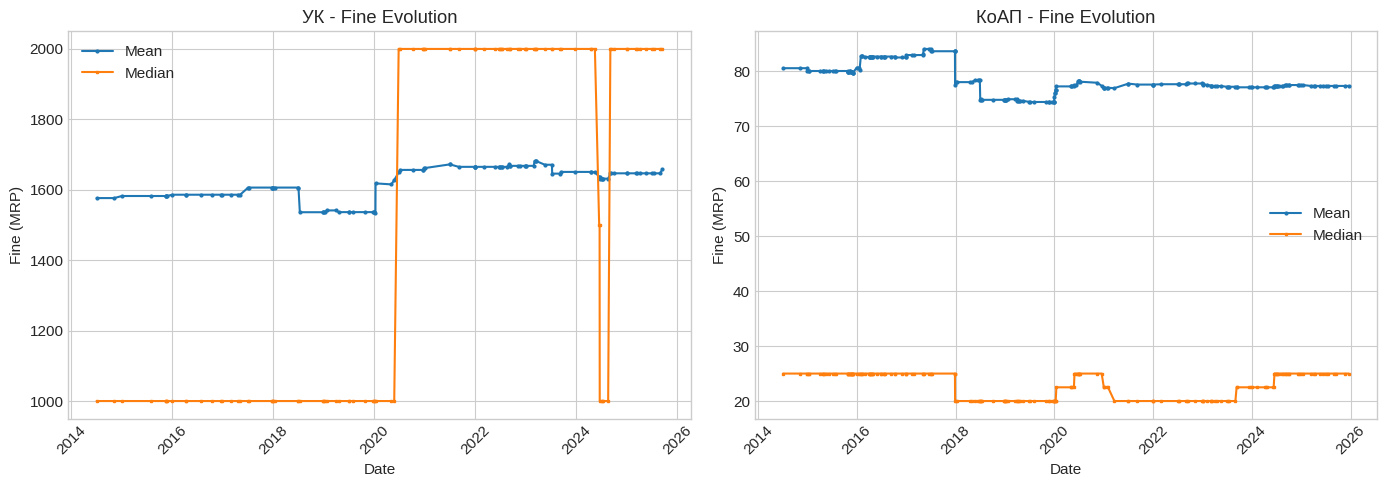

In [62]:
# Average fine over time
fine_df = penalties_df[penalties_df['penalty_type'] == 'fine_mrp'].copy()

# Get latest penalty value per article per version
fine_by_version = fine_df.groupby(['code_short', 'version_number', 'version_date']).agg({
    'penalty_max': ['mean', 'median', 'max', 'count']
}).reset_index()
fine_by_version.columns = ['code_short', 'version_number', 'version_date', 
                           'mean_fine', 'median_fine', 'max_fine', 'count']
fine_by_version['version_date'] = pd.to_datetime(fine_by_version['version_date'])

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, code_short in enumerate(['УК', 'КоАП']):
    ax = axes[idx]
    code_data = fine_by_version[fine_by_version['code_short'] == code_short]
    
    ax.plot(code_data['version_date'], code_data['mean_fine'], label='Mean', marker='o', markersize=2)
    ax.plot(code_data['version_date'], code_data['median_fine'], label='Median', marker='s', markersize=2)
    
    ax.set_xlabel('Date')
    ax.set_ylabel('Fine (MRP)')
    ax.set_title(f'{code_short} - Fine Evolution')
    ax.legend()
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fine_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

In [97]:
# Fine change statistics - helper function
fine_changes = all_changes[all_changes['penalty_type'] == 'fine_mrp']

# Extract document IDs for adilet links
DOC_IDS = {
    'criminal': 'K1400000226',
    'administrative': 'K1400000235'
}

def make_adilet_link(doc_id, date):
    """Create adilet.zan.kz link to specific historical version."""
    date_str = pd.to_datetime(date).strftime('%d.%m.%Y')
    return f"https://adilet.zan.kz/rus/docs/{doc_id}/{date_str}"

def analyze_fine_changes(changes_df, year_from, year_to, title):
    """Analyze fine changes for a specific year range."""
    # Filter by year range
    filtered = changes_df[(changes_df['year'] >= year_from) & (changes_df['year'] <= year_to)]
    
    if len(filtered) == 0:
        print(f"\n{title}")
        print("=" * 80)
        print("No fine changes in this period.")
        return
    
    print(f"\n{title}")
    print("=" * 80)
    
    for code_short in ['УК', 'КоАП']:
        code_changes = filtered[filtered['code_short'] == code_short]
        if len(code_changes) > 0:
            increases = code_changes[code_changes['change_abs'] > 0]
            decreases = code_changes[code_changes['change_abs'] < 0]
            
            print(f"\n{code_short}:")
            print(f"  Total fine changes: {len(code_changes):,}")
            if len(increases) > 0:
                print(f"  Increases: {len(increases):,} (avg: +{increases['change_pct'].mean():.1f}%)")
            if len(decreases) > 0:
                print(f"  Decreases: {len(decreases):,} (avg: {decreases['change_pct'].mean():.1f}%)")
            
            # Biggest increases with full details
            if len(increases) > 0:
                print(f"\n  Top 5 Biggest Increases:")
                print(f"  {'-'*75}")
                for _, row in increases.nlargest(3, 'change_abs').iterrows():
                    date_from = pd.to_datetime(row['date_from']).strftime('%Y-%m-%d')
                    date_to = pd.to_datetime(row['date_to']).strftime('%Y-%m-%d')
                    doc_id = DOC_IDS[row['code_key']]
                    link_from = make_adilet_link(doc_id, row['date_from'])
                    link_to = make_adilet_link(doc_id, row['date_to'])
                    print(f"    Статья {row['article_number']}: {row['value_from']:.0f} → {row['value_to']:.0f} MRP (+{row['change_pct']:.0f}%)")
                    print(f"      Version: {row['version_from']} → {row['version_to']} | Date: {date_from} → {date_to}")
                    print(f"      From: {link_from}")
                    print(f"      To:   {link_to}")
                    print()
            
            # Biggest decreases with full details
            if len(decreases) > 0:
                print(f"\n  Top 5 Biggest Decreases:")
                print(f"  {'-'*75}")
                for _, row in decreases.nsmallest(2, 'change_abs').iterrows():
                    date_from = pd.to_datetime(row['date_from']).strftime('%Y-%m-%d')
                    date_to = pd.to_datetime(row['date_to']).strftime('%Y-%m-%d')
                    doc_id = DOC_IDS[row['code_key']]
                    link_from = make_adilet_link(doc_id, row['date_from'])
                    link_to = make_adilet_link(doc_id, row['date_to'])
                    print(f"    Статья {row['article_number']}: {row['value_from']:.0f} → {row['value_to']:.0f} MRP ({row['change_pct']:.0f}%)")
                    print(f"      Version: {row['version_from']} → {row['version_to']} | Date: {date_from} → {date_to}")
                    print(f"      From: {link_from}")
                    print(f"      To:   {link_to}")
                    print()

print("Fine change analysis functions defined.")

Fine change analysis functions defined.


### 6.1 Fine Changes

In [98]:
# Fine changes 2014-2017
analyze_fine_changes(fine_changes, 2014, 2017, "Fine (MRP) Changes: 2014-2017")


Fine (MRP) Changes: 2014-2017

УК:
  Total fine changes: 15
  Increases: 6 (avg: +483.3%)
  Decreases: 9 (avg: -57.8%)

  Top 5 Biggest Increases:
  ---------------------------------------------------------------------------
    Статья 244: 500 → 3000 MRP (+500%)
      Version: 18 → 19 | Date: 2017-05-06 → 2017-07-03
      From: https://adilet.zan.kz/rus/docs/K1400000226/06.05.2017
      To:   https://adilet.zan.kz/rus/docs/K1400000226/03.07.2017

    Статья 379: 100 → 2000 MRP (+1900%)
      Version: 18 → 19 | Date: 2017-05-06 → 2017-07-03
      From: https://adilet.zan.kz/rus/docs/K1400000226/06.05.2017
      To:   https://adilet.zan.kz/rus/docs/K1400000226/03.07.2017

    Статья 441: 500 → 2000 MRP (+300%)
      Version: 2 → 3 | Date: 2014-11-07 → 2015-01-01
      From: https://adilet.zan.kz/rus/docs/K1400000226/07.11.2014
      To:   https://adilet.zan.kz/rus/docs/K1400000226/01.01.2015


  Top 5 Biggest Decreases:
  ----------------------------------------------------------------

In [99]:
# Fine changes 2017-2021
analyze_fine_changes(fine_changes, 2017, 2021, "Fine (MRP) Changes: 2017-2021")


Fine (MRP) Changes: 2017-2021

УК:
  Total fine changes: 130
  Increases: 21 (avg: +526.7%)
  Decreases: 109 (avg: -46.2%)

  Top 5 Biggest Increases:
  ---------------------------------------------------------------------------
    Статья 346: 200 → 5000 MRP (+2400%)
      Version: 43 → 44 | Date: 2020-01-10 → 2020-01-11
      From: https://adilet.zan.kz/rus/docs/K1400000226/10.01.2020
      To:   https://adilet.zan.kz/rus/docs/K1400000226/11.01.2020

    Статья 335: 160 → 3000 MRP (+1775%)
      Version: 43 → 44 | Date: 2020-01-10 → 2020-01-11
      From: https://adilet.zan.kz/rus/docs/K1400000226/10.01.2020
      To:   https://adilet.zan.kz/rus/docs/K1400000226/11.01.2020

    Статья 337: 160 → 3000 MRP (+1775%)
      Version: 43 → 44 | Date: 2020-01-10 → 2020-01-11
      From: https://adilet.zan.kz/rus/docs/K1400000226/10.01.2020
      To:   https://adilet.zan.kz/rus/docs/K1400000226/11.01.2020


  Top 5 Biggest Decreases:
  --------------------------------------------------------

In [100]:
analyze_fine_changes(fine_changes, 2021, 2023, "Fine (MRP) Changes: 2021-2023")


Fine (MRP) Changes: 2021-2023

УК:
  Total fine changes: 10
  Increases: 8 (avg: +434.4%)
  Decreases: 2 (avg: -46.7%)

  Top 5 Biggest Increases:
  ---------------------------------------------------------------------------
    Статья 343: 160 → 3000 MRP (+1775%)
      Version: 53 → 54 | Date: 2021-01-02 → 2021-07-01
      From: https://adilet.zan.kz/rus/docs/K1400000226/02.01.2021
      To:   https://adilet.zan.kz/rus/docs/K1400000226/01.07.2021

    Статья 334: 200 → 3000 MRP (+1400%)
      Version: 77 → 78 | Date: 2023-02-28 → 2023-03-07
      From: https://adilet.zan.kz/rus/docs/K1400000226/28.02.2023
      To:   https://adilet.zan.kz/rus/docs/K1400000226/07.03.2023

    Статья 218: 3000 → 5000 MRP (+67%)
      Version: 68 → 69 | Date: 2022-08-21 → 2022-09-03
      From: https://adilet.zan.kz/rus/docs/K1400000226/21.08.2022
      To:   https://adilet.zan.kz/rus/docs/K1400000226/03.09.2022


  Top 5 Biggest Decreases:
  -------------------------------------------------------------

### 6.5 Fine Changes: 2022-2023

In [101]:
analyze_fine_changes(fine_changes, 2023, 2025, "Fine (MRP) Changes: 2023-2025")


Fine (MRP) Changes: 2023-2025

УК:
  Total fine changes: 13
  Increases: 11 (avg: +633.3%)
  Decreases: 2 (avg: -55.0%)

  Top 5 Biggest Increases:
  ---------------------------------------------------------------------------
    Статья 234: 80 → 3000 MRP (+3650%)
      Version: 96 → 97 | Date: 2024-08-20 → 2024-09-05
      From: https://adilet.zan.kz/rus/docs/K1400000226/20.08.2024
      To:   https://adilet.zan.kz/rus/docs/K1400000226/05.09.2024

    Статья 334: 200 → 3000 MRP (+1400%)
      Version: 77 → 78 | Date: 2023-02-28 → 2023-03-07
      From: https://adilet.zan.kz/rus/docs/K1400000226/28.02.2023
      To:   https://adilet.zan.kz/rus/docs/K1400000226/07.03.2023

    Статья 459: 2000 → 4000 MRP (+100%)
      Version: 108 → 109 | Date: 2025-08-31 → 2025-09-16
      From: https://adilet.zan.kz/rus/docs/K1400000226/31.08.2025
      To:   https://adilet.zan.kz/rus/docs/K1400000226/16.09.2025


  Top 5 Biggest Decreases:
  ----------------------------------------------------------

### 6.7 Fine Changes: Summary by Period

In [70]:
# Summary comparison across periods (2-year ranges)
periods = [
    (2014, 2015, "2014-2015"),
    (2016, 2017, "2016-2017"),
    (2018, 2019, "2018-2019"),
    (2020, 2021, "2020-2021"),
    (2022, 2023, "2022-2023"),
    (2024, 2025, "2024-2025")
]

print("Fine (MRP) Changes - Period Comparison (2-year ranges)")
print("=" * 80)
print(f"{'Period':<15} {'Total':>8} {'Increases':>12} {'Decreases':>12} {'Trend':>12}")
print("-" * 80)

for year_from, year_to, label in periods:
    filtered = fine_changes[(fine_changes['year'] >= year_from) & (fine_changes['year'] <= year_to)]
    total = len(filtered)
    increases = len(filtered[filtered['change_abs'] > 0])
    decreases = len(filtered[filtered['change_abs'] < 0])
    
    if total > 0:
        inc_pct = increases / total * 100
        dec_pct = decreases / total * 100
        trend = "↑ HARSHER" if inc_pct > dec_pct else "↓ LENIENT" if dec_pct > inc_pct else "→ STABLE"
        print(f"{label:<15} {total:>8} {increases:>6} ({inc_pct:>4.0f}%) {decreases:>6} ({dec_pct:>4.0f}%) {trend:>12}")
    else:
        print(f"{label:<15} {total:>8} {'N/A':>12} {'N/A':>12} {'N/A':>12}")

Fine (MRP) Changes - Period Comparison (2-year ranges)
Period             Total    Increases    Decreases        Trend
--------------------------------------------------------------------------------
2014-2015              4      3 (  75%)      1 (  25%)    ↑ HARSHER
2016-2017             58     17 (  29%)     41 (  71%)    ↓ LENIENT
2018-2019            104      1 (   1%)    103 (  99%)    ↓ LENIENT
2020-2021             32     23 (  72%)      9 (  28%)    ↑ HARSHER
2022-2023             13     11 (  85%)      2 (  15%)    ↑ HARSHER
2024-2025             24     19 (  79%)      5 (  21%)    ↑ HARSHER


## 7. Analyze Imprisonment Term Evolution

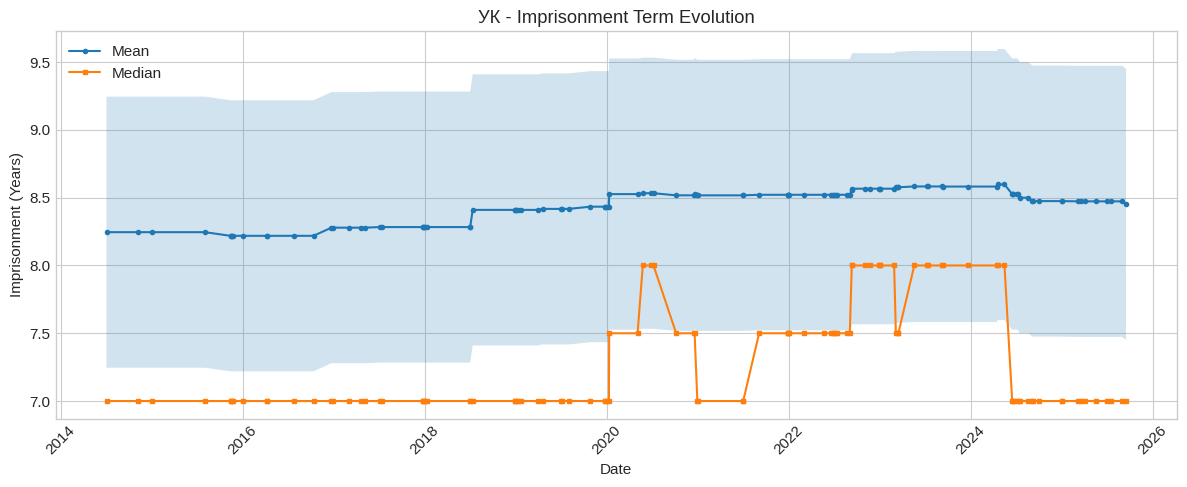

In [71]:
# Imprisonment statistics over time (only for УК)
prison_df = penalties_df[(penalties_df['penalty_type'] == 'imprisonment_years') & 
                          (penalties_df['code_short'] == 'УК')].copy()

if len(prison_df) > 0:
    prison_by_version = prison_df.groupby(['version_number', 'version_date']).agg({
        'penalty_max': ['mean', 'median', 'max', 'count']
    }).reset_index()
    prison_by_version.columns = ['version_number', 'version_date', 
                                  'mean_years', 'median_years', 'max_years', 'count']
    prison_by_version['version_date'] = pd.to_datetime(prison_by_version['version_date'])
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, 5))
    
    ax.plot(prison_by_version['version_date'], prison_by_version['mean_years'], 
            label='Mean', marker='o', markersize=3)
    ax.plot(prison_by_version['version_date'], prison_by_version['median_years'], 
            label='Median', marker='s', markersize=3)
    ax.fill_between(prison_by_version['version_date'], 
                    prison_by_version['mean_years'] - 1,
                    prison_by_version['mean_years'] + 1, alpha=0.2)
    
    ax.set_xlabel('Date')
    ax.set_ylabel('Imprisonment (Years)')
    ax.set_title('УК - Imprisonment Term Evolution')
    ax.legend()
    ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'imprisonment_evolution.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No imprisonment data found.")

In [72]:
# Imprisonment change statistics - helper function
prison_changes = all_changes[all_changes['penalty_type'] == 'imprisonment_years']

def analyze_imprisonment_changes(changes_df, year_from, year_to, title):
    """Analyze imprisonment changes for a specific year range."""
    # Filter by year range
    filtered = changes_df[(changes_df['year'] >= year_from) & (changes_df['year'] <= year_to)]
    
    if len(filtered) == 0:
        print(f"\n{title}")
        print("=" * 80)
        print("No imprisonment changes in this period.")
        return
    
    print(f"\n{title}")
    print("=" * 80)
    
    for code_short in ['УК']:  # Imprisonment only in Criminal Code
        code_changes = filtered[filtered['code_short'] == code_short]
        if len(code_changes) > 0:
            increases = code_changes[code_changes['change_abs'] > 0]
            decreases = code_changes[code_changes['change_abs'] < 0]
            
            print(f"\n{code_short}:")
            print(f"  Total imprisonment changes: {len(code_changes):,}")
            if len(increases) > 0:
                print(f"  Increases (harsher): {len(increases):,} (avg: +{increases['change_abs'].mean():.1f} years)")
            if len(decreases) > 0:
                print(f"  Decreases (lenient): {len(decreases):,} (avg: {decreases['change_abs'].mean():.1f} years)")
            
            # Biggest increases with full details
            if len(increases) > 0:
                print(f"\n  Top 5 Biggest Increases (Harsher):")
                print(f"  {'-'*75}")
                for _, row in increases.nlargest(5, 'change_abs').iterrows():
                    date_from = pd.to_datetime(row['date_from']).strftime('%Y-%m-%d')
                    date_to = pd.to_datetime(row['date_to']).strftime('%Y-%m-%d')
                    doc_id = DOC_IDS[row['code_key']]
                    link_from = make_adilet_link(doc_id, row['date_from'])
                    link_to = make_adilet_link(doc_id, row['date_to'])
                    print(f"    Статья {row['article_number']}: {row['value_from']:.0f} → {row['value_to']:.0f} лет (+{row['change_abs']:.0f})")
                    print(f"      Version: {row['version_from']} → {row['version_to']} | Date: {date_from} → {date_to}")
                    print(f"      From: {link_from}")
                    print(f"      To:   {link_to}")
                    print()
            
            # Biggest decreases with full details
            if len(decreases) > 0:
                print(f"\n  Top 5 Biggest Decreases (More Lenient):")
                print(f"  {'-'*75}")
                for _, row in decreases.nsmallest(5, 'change_abs').iterrows():
                    date_from = pd.to_datetime(row['date_from']).strftime('%Y-%m-%d')
                    date_to = pd.to_datetime(row['date_to']).strftime('%Y-%m-%d')
                    doc_id = DOC_IDS[row['code_key']]
                    link_from = make_adilet_link(doc_id, row['date_from'])
                    link_to = make_adilet_link(doc_id, row['date_to'])
                    print(f"    Статья {row['article_number']}: {row['value_from']:.0f} → {row['value_to']:.0f} лет ({row['change_abs']:.0f})")
                    print(f"      Version: {row['version_from']} → {row['version_to']} | Date: {date_from} → {date_to}")
                    print(f"      From: {link_from}")
                    print(f"      To:   {link_to}")
                    print()

print(f"Imprisonment changes loaded: {len(prison_changes)} total")
print("Imprisonment change analysis function defined.")

Imprisonment changes loaded: 52 total
Imprisonment change analysis function defined.


### 7.1 Imprisonment Changes: 2014-2015

In [73]:
# Imprisonment changes 2014-2015
analyze_imprisonment_changes(prison_changes, 2014, 2015, "Imprisonment Changes: 2014-2015")


Imprisonment Changes: 2014-2015
No imprisonment changes in this period.


### 7.2 Imprisonment Changes: 2016-2017

In [74]:
# Imprisonment changes 2016-2017
analyze_imprisonment_changes(prison_changes, 2016, 2017, "Imprisonment Changes: 2016-2017")


Imprisonment Changes: 2016-2017

УК:
  Total imprisonment changes: 9
  Increases (harsher): 7 (avg: +2.0 years)
  Decreases (lenient): 2 (avg: -2.0 years)

  Top 5 Biggest Increases (Harsher):
  ---------------------------------------------------------------------------
    Статья 170: 10 → 12 лет (+2)
      Version: 13 → 14 | Date: 2016-10-11 → 2016-12-22
      From: https://adilet.zan.kz/rus/docs/K1400000226/11.10.2016
      To:   https://adilet.zan.kz/rus/docs/K1400000226/22.12.2016

    Статья 171: 10 → 12 лет (+2)
      Version: 13 → 14 | Date: 2016-10-11 → 2016-12-22
      From: https://adilet.zan.kz/rus/docs/K1400000226/11.10.2016
      To:   https://adilet.zan.kz/rus/docs/K1400000226/22.12.2016

    Статья 172: 7 → 9 лет (+2)
      Version: 13 → 14 | Date: 2016-10-11 → 2016-12-22
      From: https://adilet.zan.kz/rus/docs/K1400000226/11.10.2016
      To:   https://adilet.zan.kz/rus/docs/K1400000226/22.12.2016

    Статья 182: 15 → 17 лет (+2)
      Version: 13 → 14 | Date: 201

### 7.3 Imprisonment Changes: 2018-2019

In [75]:
# Imprisonment changes 2018-2019
analyze_imprisonment_changes(prison_changes, 2018, 2019, "Imprisonment Changes: 2018-2019")


Imprisonment Changes: 2018-2019

УК:
  Total imprisonment changes: 6
  Increases (harsher): 3 (avg: +2.0 years)
  Decreases (lenient): 3 (avg: -2.7 years)

  Top 5 Biggest Increases (Harsher):
  ---------------------------------------------------------------------------
    Статья 188: 7 → 10 лет (+3)
      Version: 27 → 28 | Date: 2018-07-02 → 2018-07-12
      From: https://adilet.zan.kz/rus/docs/K1400000226/02.07.2018
      To:   https://adilet.zan.kz/rus/docs/K1400000226/12.07.2018

    Статья 362: 8 → 10 лет (+2)
      Version: 27 → 28 | Date: 2018-07-02 → 2018-07-12
      From: https://adilet.zan.kz/rus/docs/K1400000226/02.07.2018
      To:   https://adilet.zan.kz/rus/docs/K1400000226/12.07.2018

    Статья 46: 1 → 2 лет (+1)
      Version: 27 → 28 | Date: 2018-07-02 → 2018-07-12
      From: https://adilet.zan.kz/rus/docs/K1400000226/02.07.2018
      To:   https://adilet.zan.kz/rus/docs/K1400000226/12.07.2018


  Top 5 Biggest Decreases (More Lenient):
  -------------------------

### 7.4 Imprisonment Changes: 2020-2021

In [76]:
# Imprisonment changes 2020-2021
analyze_imprisonment_changes(prison_changes, 2020, 2021, "Imprisonment Changes: 2020-2021")


Imprisonment Changes: 2020-2021

УК:
  Total imprisonment changes: 19
  Increases (harsher): 17 (avg: +1.9 years)
  Decreases (lenient): 2 (avg: -1.5 years)

  Top 5 Biggest Increases (Harsher):
  ---------------------------------------------------------------------------
    Статья 335: 5 → 10 лет (+5)
      Version: 43 → 44 | Date: 2020-01-10 → 2020-01-11
      From: https://adilet.zan.kz/rus/docs/K1400000226/10.01.2020
      To:   https://adilet.zan.kz/rus/docs/K1400000226/11.01.2020

    Статья 120: 5 → 8 лет (+3)
      Version: 43 → 44 | Date: 2020-01-10 → 2020-01-11
      From: https://adilet.zan.kz/rus/docs/K1400000226/10.01.2020
      To:   https://adilet.zan.kz/rus/docs/K1400000226/11.01.2020

    Статья 121: 5 → 8 лет (+3)
      Version: 43 → 44 | Date: 2020-01-10 → 2020-01-11
      From: https://adilet.zan.kz/rus/docs/K1400000226/10.01.2020
      To:   https://adilet.zan.kz/rus/docs/K1400000226/11.01.2020

    Статья 337: 7 → 10 лет (+3)
      Version: 43 → 44 | Date: 2020-

### 7.5 Imprisonment Changes: 2022-2023

In [77]:
# Imprisonment changes 2022-2023
analyze_imprisonment_changes(prison_changes, 2022, 2023, "Imprisonment Changes: 2022-2023")


Imprisonment Changes: 2022-2023

УК:
  Total imprisonment changes: 8
  Increases (harsher): 7 (avg: +3.4 years)
  Decreases (lenient): 1 (avg: -3.0 years)

  Top 5 Biggest Increases (Harsher):
  ---------------------------------------------------------------------------
    Статья 195: 5 → 10 лет (+5)
      Version: 27 → 85 | Date: 2018-07-02 → 2023-09-12
      From: https://adilet.zan.kz/rus/docs/K1400000226/02.07.2018
      To:   https://adilet.zan.kz/rus/docs/K1400000226/12.09.2023

    Статья 340: 5 → 10 лет (+5)
      Version: 77 → 78 | Date: 2023-02-28 → 2023-03-07
      From: https://adilet.zan.kz/rus/docs/K1400000226/28.02.2023
      To:   https://adilet.zan.kz/rus/docs/K1400000226/07.03.2023

    Статья 409: 10 → 15 лет (+5)
      Version: 69 → 70 | Date: 2022-09-03 → 2022-09-11
      From: https://adilet.zan.kz/rus/docs/K1400000226/03.09.2022
      To:   https://adilet.zan.kz/rus/docs/K1400000226/11.09.2022

    Статья 146: 7 → 10 лет (+3)
      Version: 80 → 81 | Date: 2023

### 7.6 Imprisonment Changes: 2024-2025

In [78]:
# Imprisonment changes 2024-2025
analyze_imprisonment_changes(prison_changes, 2024, 2025, "Imprisonment Changes: 2024-2025")


Imprisonment Changes: 2024-2025

УК:
  Total imprisonment changes: 10
  Increases (harsher): 4 (avg: +2.0 years)
  Decreases (lenient): 6 (avg: -3.8 years)

  Top 5 Biggest Increases (Harsher):
  ---------------------------------------------------------------------------
    Статья 394: 7 → 10 лет (+3)
      Version: 108 → 109 | Date: 2025-08-31 → 2025-09-16
      From: https://adilet.zan.kz/rus/docs/K1400000226/31.08.2025
      To:   https://adilet.zan.kz/rus/docs/K1400000226/16.09.2025

    Статья 392: 1 → 3 лет (+2)
      Version: 108 → 109 | Date: 2025-08-31 → 2025-09-16
      From: https://adilet.zan.kz/rus/docs/K1400000226/31.08.2025
      To:   https://adilet.zan.kz/rus/docs/K1400000226/16.09.2025

    Статья 445: 5 → 7 лет (+2)
      Version: 108 → 109 | Date: 2025-08-31 → 2025-09-16
      From: https://adilet.zan.kz/rus/docs/K1400000226/31.08.2025
      To:   https://adilet.zan.kz/rus/docs/K1400000226/16.09.2025

    Статья 105: 8 → 9 лет (+1)
      Version: 89 → 90 | Date: 2

### 7.7 Imprisonment Changes: Summary by Period

In [79]:
# Summary comparison across periods (2-year ranges) - Imprisonment
periods = [
    (2014, 2015, "2014-2015"),
    (2016, 2017, "2016-2017"),
    (2018, 2019, "2018-2019"),
    (2020, 2021, "2020-2021"),
    (2022, 2023, "2022-2023"),
    (2024, 2025, "2024-2025")
]

print("Imprisonment Term Changes - Period Comparison (2-year ranges)")
print("=" * 85)
print(f"{'Period':<15} {'Total':>8} {'Increases':>14} {'Decreases':>14} {'Trend':>12}")
print("-" * 85)

for year_from, year_to, label in periods:
    filtered = prison_changes[(prison_changes['year'] >= year_from) & (prison_changes['year'] <= year_to)]
    total = len(filtered)
    increases = len(filtered[filtered['change_abs'] > 0])
    decreases = len(filtered[filtered['change_abs'] < 0])
    
    if total > 0:
        inc_pct = increases / total * 100
        dec_pct = decreases / total * 100
        trend = "↑ HARSHER" if inc_pct > dec_pct else "↓ LENIENT" if dec_pct > inc_pct else "→ STABLE"
        print(f"{label:<15} {total:>8} {increases:>6} ({inc_pct:>5.1f}%) {decreases:>6} ({dec_pct:>5.1f}%) {trend:>12}")
    else:
        print(f"{label:<15} {total:>8} {'N/A':>14} {'N/A':>14} {'N/A':>12}")

Imprisonment Term Changes - Period Comparison (2-year ranges)
Period             Total      Increases      Decreases        Trend
-------------------------------------------------------------------------------------
2014-2015              0            N/A            N/A          N/A
2016-2017              9      7 ( 77.8%)      2 ( 22.2%)    ↑ HARSHER
2018-2019              6      3 ( 50.0%)      3 ( 50.0%)     → STABLE
2020-2021             19     17 ( 89.5%)      2 ( 10.5%)    ↑ HARSHER
2022-2023              8      7 ( 87.5%)      1 ( 12.5%)    ↑ HARSHER
2024-2025             10      4 ( 40.0%)      6 ( 60.0%)    ↓ LENIENT


## 8. Penalty Change Heatmap by Year

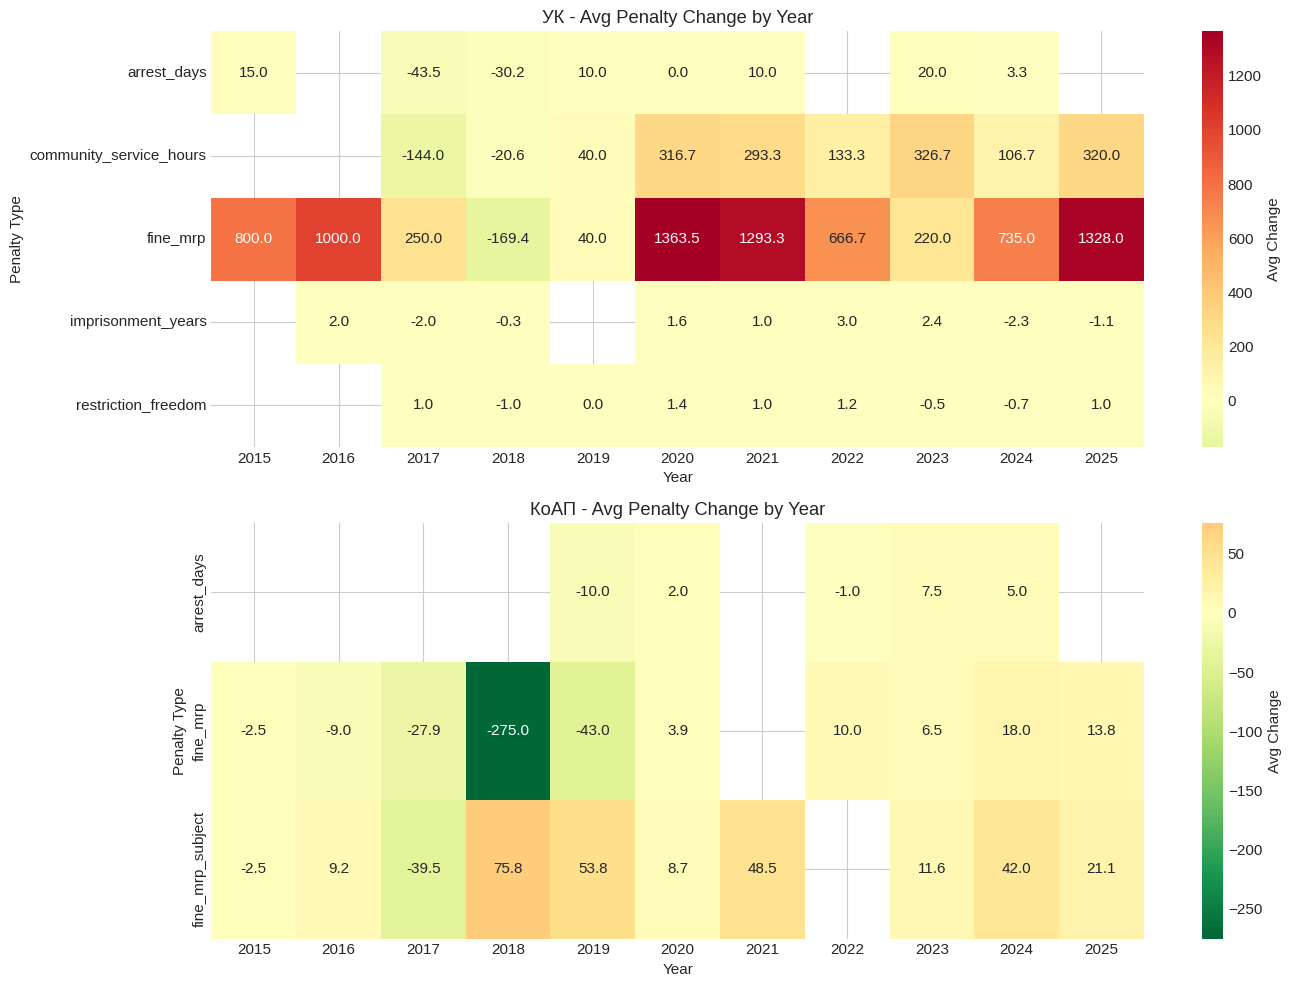

In [81]:
# Heatmap of penalty changes by year and type
if len(all_changes) > 0:
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    for idx, code_short in enumerate(['УК', 'КоАП']):
        ax = axes[idx]
        code_changes = all_changes[all_changes['code_short'] == code_short]
        
        if len(code_changes) > 0:
            pivot = code_changes.pivot_table(
                values='change_abs', 
                index='penalty_type', 
                columns='year', 
                aggfunc='mean'
            )
            
            sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r', 
                        center=0, ax=ax, cbar_kws={'label': 'Avg Change'})
            ax.set_title(f'{code_short} - Avg Penalty Change by Year')
            ax.set_xlabel('Year')
            ax.set_ylabel('Penalty Type')
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center')
            ax.set_title(f'{code_short}')
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'penalty_change_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No changes to visualize.")

## 9. Penalty Evolution and Major Events

Correlation of penalty changes with major political, economic, and social events in Kazakhstan (2014-2025).

/tmp/ipykernel_587939/1468021278.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  yearly_direction = all_changes.groupby('year').apply(


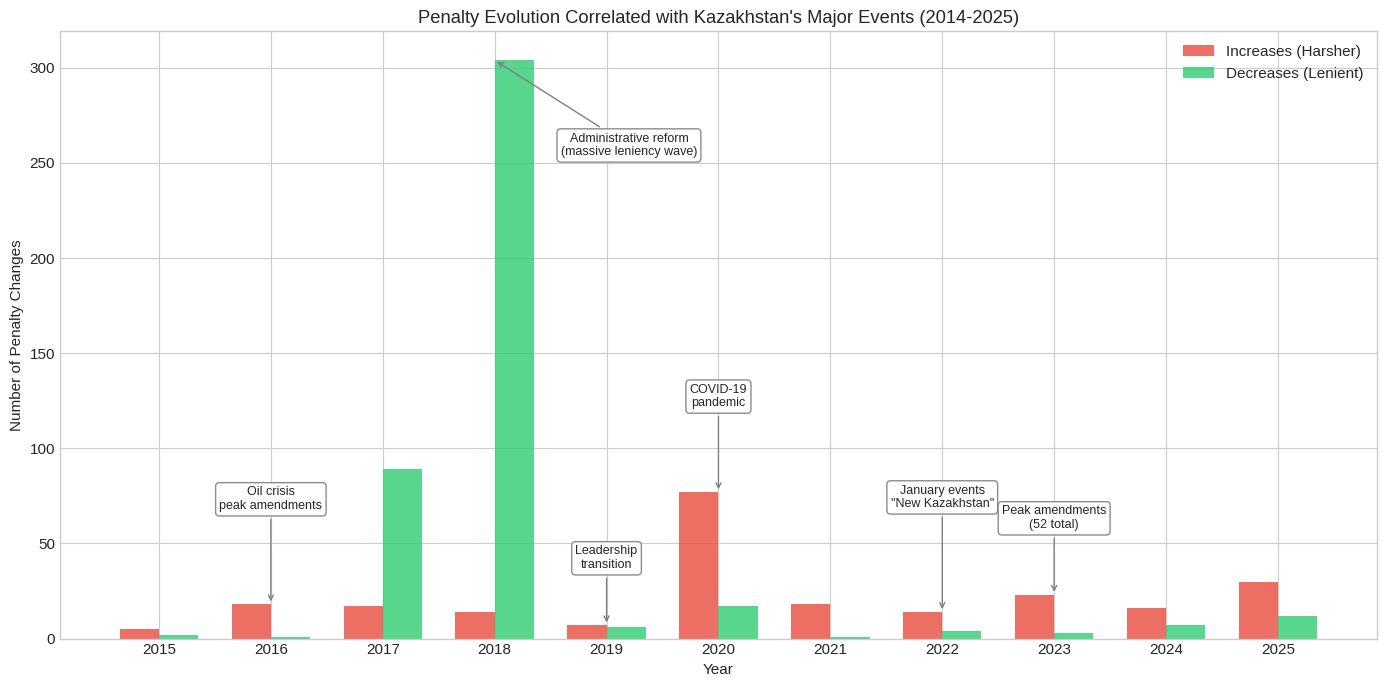


Key observations:
- 2018: Massive leniency wave (300+ decreases) - Administrative reform period
- 2020: COVID-19 triggered penalty adjustments (increases outpaced decreases)
- 2022-2023: 'New Kazakhstan' reforms - balanced approach to penalties


In [88]:
# Penalty evolution correlated with Kazakhstan's major events
if len(all_changes) > 0:
    # Prepare yearly data
    yearly_direction = all_changes.groupby('year').apply(
        lambda x: pd.Series({
            'increases': len(x[x['change_abs'] > 0]),
            'decreases': len(x[x['change_abs'] < 0])
        })
    ).reset_index()
    
    # Create figure
    fig, ax = plt.subplots(figsize=(14, 7))
    
    x = yearly_direction['year']
    width = 0.35
    
    bars1 = ax.bar(x - width/2, yearly_direction['increases'], width, 
                   label='Increases (Harsher)', color='#e74c3c', alpha=0.8)
    bars2 = ax.bar(x + width/2, yearly_direction['decreases'], width, 
                   label='Decreases (Lenient)', color='#2ecc71', alpha=0.8)
    
    ax.set_xlabel('Year')
    ax.set_ylabel('Number of Penalty Changes')
    ax.set_title("Penalty Evolution Correlated with Kazakhstan's Major Events (2014-2025)")
    ax.legend()
    ax.set_xticks(x)
    
    # Add major events annotations (year, label, y_offset, x_offset)
    events = [
        (2016, 'Oil crisis\npeak amendments', 50, 0),
        (2018, 'Administrative reform\n(massive leniency wave)', -50, 1.2),
        (2019, 'Leadership\ntransition', 30, 0),
        (2020, 'COVID-19\npandemic', 45, 0),
        (2022, 'January events\n"New Kazakhstan"', 55, 0),
        (2023, 'Peak amendments\n(52 total)', 35, 0),
    ]
    
    for year, label, y_offset, x_offset in events:
        if year in yearly_direction['year'].values:
            row = yearly_direction[yearly_direction['year'] == year].iloc[0]
            max_val = max(row['increases'], row['decreases'])
            
            ax.annotate(label, xy=(year, max_val), xytext=(year + x_offset, max_val + y_offset),
                       fontsize=9, ha='center',
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.9),
                       arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', color='gray'))
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'penalty_events_correlation.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\nKey observations:")
    print("- 2018: Massive leniency wave (300+ decreases) - Administrative reform period")
    print("- 2020: COVID-19 triggered penalty adjustments (increases outpaced decreases)")
    print("- 2022-2023: 'New Kazakhstan' reforms - balanced approach to penalties")
else:
    print("No changes to visualize.")

## 10. Articles with Most Penalty Changes

In [82]:
# Find articles with most penalty changes
if len(all_changes) > 0:
    article_change_counts = all_changes.groupby(['code_short', 'article_number', 'penalty_type']).agg({
        'change_abs': ['count', 'sum', 'mean']
    }).reset_index()
    article_change_counts.columns = ['code_short', 'article_number', 'penalty_type', 
                                      'change_count', 'total_change', 'avg_change']
    
    print("Articles with Most Penalty Changes:")
    print("=" * 70)
    
    for penalty_type in ['fine_mrp', 'imprisonment_years']:
        type_data = article_change_counts[article_change_counts['penalty_type'] == penalty_type]
        if len(type_data) > 0:
            print(f"\n{penalty_type.upper()}:")
            top_changed = type_data.nlargest(10, 'change_count')
            for _, row in top_changed.iterrows():
                direction = '↑' if row['total_change'] > 0 else '↓' if row['total_change'] < 0 else '→'
                print(f"  {row['code_short']:<5} Ст.{row['article_number']:<8} | "
                      f"{row['change_count']:>2} changes | "
                      f"total: {row['total_change']:>+8.1f} {direction}")
else:
    print("No penalty changes to analyze.")

Articles with Most Penalty Changes:

FINE_MRP:
  КоАП  Ст.228      |  3 changes | total:     +0.0 →
  УК    Ст.140      |  3 changes | total:   +800.0 ↑
  УК    Ст.234      |  3 changes | total:  +2500.0 ↑
  УК    Ст.236      |  3 changes | total:   -340.0 ↓
  КоАП  Ст.127      |  2 changes | total:     +3.0 ↑
  КоАП  Ст.213      |  2 changes | total:   -400.0 ↓
  КоАП  Ст.238      |  2 changes | total:     +0.0 →
  КоАП  Ст.434      |  2 changes | total:    +10.0 ↑
  КоАП  Ст.602      |  2 changes | total:     +0.0 →
  КоАП  Ст.613      |  2 changes | total:    +20.0 ↑

IMPRISONMENT_YEARS:
  УК    Ст.105      |  2 changes | total:     +2.0 ↑
  УК    Ст.122      |  2 changes | total:     -4.0 ↓
  УК    Ст.217      |  2 changes | total:     +0.0 →
  УК    Ст.106      |  1 changes | total:     -2.0 ↓
  УК    Ст.120      |  1 changes | total:     +3.0 ↑
  УК    Ст.121      |  1 changes | total:     +3.0 ↑
  УК    Ст.124      |  1 changes | total:     +2.0 ↑
  УК    Ст.127      |  1 change

## 11. Export Results

In [83]:
# Export penalty records
penalties_df.to_csv(OUTPUT_DIR / 'penalty_history.csv', index=False)
print(f"Exported {len(penalties_df):,} penalty records to penalty_history.csv")

# Export changes
if len(all_changes) > 0:
    all_changes.to_csv(OUTPUT_DIR / 'penalty_changes.csv', index=False)
    print(f"Exported {len(all_changes):,} penalty changes to penalty_changes.csv")

# Export yearly summary
yearly_summary = penalties_df.groupby(['code_short', 'year', 'penalty_type']).agg({
    'penalty_max': ['mean', 'median', 'count']
}).reset_index()
yearly_summary.columns = ['code_short', 'year', 'penalty_type', 'mean_value', 'median_value', 'count']
yearly_summary.to_csv(OUTPUT_DIR / 'penalty_yearly_summary.csv', index=False)
print(f"Exported yearly summary to penalty_yearly_summary.csv")

Exported 356,546 penalty records to penalty_history.csv
Exported 685 penalty changes to penalty_changes.csv
Exported yearly summary to penalty_yearly_summary.csv


## 12. Summary

In [84]:
print("=" * 80)
print("KEY FINDINGS - Penalty Evolution Analysis (2014-2025)")
print("=" * 80)

print(f"""
1. DATA SCOPE
   {'─'*70}
   Total penalty records extracted: {len(penalties_df):,}
   Total penalty changes detected: {len(all_changes):,}
   Penalty types tracked: {penalties_df['penalty_type'].nunique()}
   Date range: {penalties_df['version_date'].min().strftime('%Y-%m-%d')} to {penalties_df['version_date'].max().strftime('%Y-%m-%d')}
""")

print("2. PENALTIES BY CODE")
print("   " + "─"*70)
for code_short in ['УК', 'КоАП']:
    code_data = penalties_df[penalties_df['code_short'] == code_short]
    code_changes = all_changes[all_changes['code_short'] == code_short]
    print(f"   {code_short}: {len(code_data):,} records, {code_data['article_number'].nunique()} articles, {len(code_changes)} changes")

print(f"""
3. OVERALL CHANGE DIRECTION
   {'─'*70}""")
if len(all_changes) > 0:
    increases = len(all_changes[all_changes['change_abs'] > 0])
    decreases = len(all_changes[all_changes['change_abs'] < 0])
    print(f"   Increases (harsher): {increases:,} ({increases/len(all_changes)*100:.1f}%)")
    print(f"   Decreases (lenient): {decreases:,} ({decreases/len(all_changes)*100:.1f}%)")
    print(f"   Overall trend: {'↓ MORE LENIENT' if decreases > increases else '↑ HARSHER'}")

print(f"""
4. CHANGE DIRECTION BY PENALTY TYPE
   {'─'*70}""")
for ptype in all_changes['penalty_type'].unique():
    type_changes = all_changes[all_changes['penalty_type'] == ptype]
    inc = len(type_changes[type_changes['change_abs'] > 0])
    dec = len(type_changes[type_changes['change_abs'] < 0])
    total = len(type_changes)
    trend = "↑ HARSHER" if inc > dec else "↓ LENIENT"
    print(f"   {ptype:25} | {total:>3} changes | +{inc/total*100:4.0f}% / -{dec/total*100:4.0f}% | {trend}")

print(f"""
{'='*80}
CONCLUSIONS:
{'='*80}
1. Overall trend is MORE LENIENT (65% decreases vs 35% increases)

2. HARSHER penalties for serious crimes:
   - Imprisonment terms: 73% increases (longer sentences)
   - Restriction of freedom: 70% increases
   - Administrative fines for officials/businesses: 58% increases

3. MORE LENIENT for minor offenses:
   - Arrest days: 90% decreases (shorter detention)
   - Community service: 75% decreases
   - Basic fines (MRP): 69% decreases

4. Policy interpretation:
   - Government is getting tougher on serious crimes (imprisonment)
   - But easing penalties for minor administrative violations
   - Shift towards proportional punishment
{'='*80}
""")

KEY FINDINGS - Penalty Evolution Analysis (2014-2025)

1. DATA SCOPE
   ──────────────────────────────────────────────────────────────────────
   Total penalty records extracted: 356,546
   Total penalty changes detected: 685
   Penalty types tracked: 14
   Date range: 2014-07-03 to 2025-12-17

2. PENALTIES BY CODE
   ──────────────────────────────────────────────────────────────────────
   УК: 153,916 records, 434 articles, 496 changes
   КоАП: 202,630 records, 672 articles, 189 changes

3. OVERALL CHANGE DIRECTION
   ──────────────────────────────────────────────────────────────────────
   Increases (harsher): 239 (34.9%)
   Decreases (lenient): 446 (65.1%)
   Overall trend: ↓ MORE LENIENT

4. CHANGE DIRECTION BY PENALTY TYPE
   ──────────────────────────────────────────────────────────────────────
   fine_mrp                  | 235 changes | +  31% / -  69% | ↓ LENIENT
   fine_mrp_subject          |  96 changes | +  58% / -  42% | ↑ HARSHER
   imprisonment_years        |  52 changes